## 1. Learning Rate ($\alpha$)
* Definition: A hyperparameter that controls how much the model's weights are adjusted in response to the estimated error during optimization.
* Use Cases:
    * All gradient-based machine learning and deep learning training loops.
* Pros:
    * Directly dictates the speed, trajectory, and stability of model convergence.
* Cons:
    * If set too high, training diverges; if set too low, training crawls or gets trapped.

### Visualizing Learning Rate Impact on Convergence

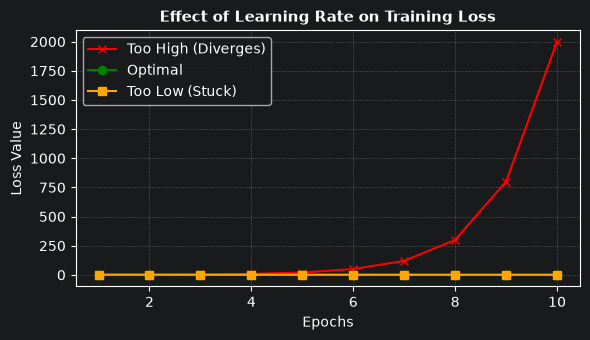

In [3]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 11)
loss_high = np.array([1.0, 1.5, 3.2, 8.5, 20.0, 50.0, 120.0, 300.0, 800.0, 2000.0]) # Diverges (Too High)
loss_good = np.array([1.0, 0.8, 0.6, 0.45, 0.35, 0.28, 0.22, 0.18, 0.15, 0.12]) # Converges (Optimal)
loss_low = np.array([1.0, 0.98, 0.96, 0.94, 0.92, 0.90, 0.88, 0.86, 0.84, 0.82])  # Too Slow

plt.figure(figsize=(6, 3.5))
plt.plot(epochs, loss_high, marker='x', color='red', label="Too High (Diverges)")
plt.plot(epochs, loss_good, marker='o', color='green', label="Optimal")
plt.plot(epochs, loss_low, marker='s', color='orange', label="Too Low (Stuck)")
plt.title("Effect of Learning Rate on Training Loss", fontsize=11, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Warmup
* Definition: A scheduling strategy where the learning rate starts at a near-zero value and increases linearly to its peak over a set number of initial steps.
* Use Cases:
    * Training massive transformer architectures and deep convolutional networks from scratch.
* Pros:
    * Stabilizes early training phases and prevents chaotic gradient explosions when weights are random.
* Cons:
    * Adds an extra hyperparameter (warmup steps duration) that requires configuration.

### Visualizing Learning Rate Warmup Curve

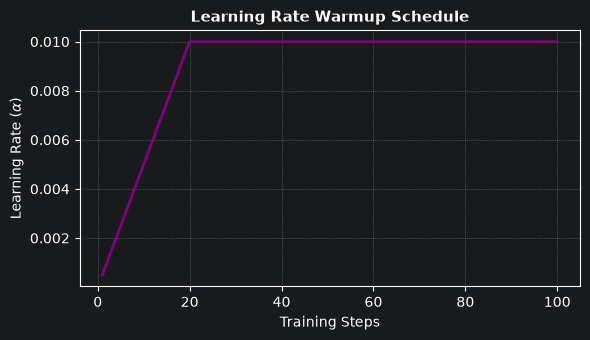

In [2]:
import numpy as np
import matplotlib.pyplot as plt

steps = np.arange(1, 101)
warmup_steps = 20
peak_lr = 0.01

# Linear warmup followed by stable phase
lr = np.where(steps <= warmup_steps, peak_lr * (steps / warmup_steps), peak_lr)

plt.figure(figsize=(6, 3.5))
plt.plot(steps, lr, color='purple', linewidth=2)
plt.title("Learning Rate Warmup Schedule", fontsize=11, fontweight='bold')
plt.xlabel("Training Steps")
plt.ylabel(r"Learning Rate ($\alpha$)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Learning Rate Scheduler
* Definition: An automated utility that dynamically changes the learning rate during training based on epochs, steps, or performance metrics.
* Use Cases:
    * Fine-tuning deep learning models to reach optimal convergence and break out of performance plateaus.
* Pros:
    * Enhances model accuracy and prevents training stagnation without manual intervention.
* Cons:
    * Introduces complexity and requires careful configuration of schedule parameters.

### Visualizing a Dynamic Learning Rate Schedule

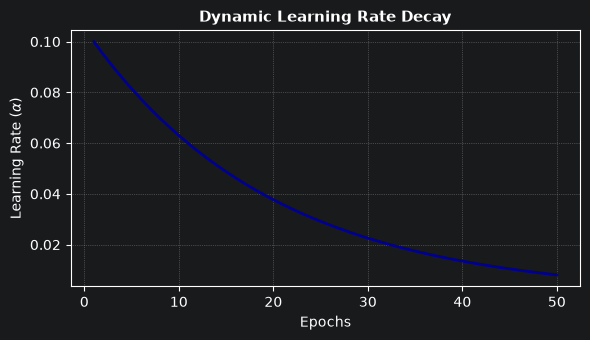

In [1]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 51)
# Simulated decay curve
lr = 0.1 * (0.95 ** (epochs - 1))

plt.figure(figsize=(6, 3.5))
plt.plot(epochs, lr, color='darkblue', linewidth=2)
plt.title("Dynamic Learning Rate Decay", fontsize=11, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel(r"Learning Rate ($\alpha$)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 4. StepLR
* Definition: A rigid scheduler that drops the learning rate by a multiplicative factor ($\gamma$) every fixed number of training epochs.
* Use Cases:
    * Standard classification networks and traditional computer vision training pipelines.
* Pros:
    * Extremely simple to implement, predictable, and transparent.
* Cons:
    * Step drops can be abrupt, potentially causing sudden turbulence in model loss.

### Visualizing StepLR Staircase Schedule

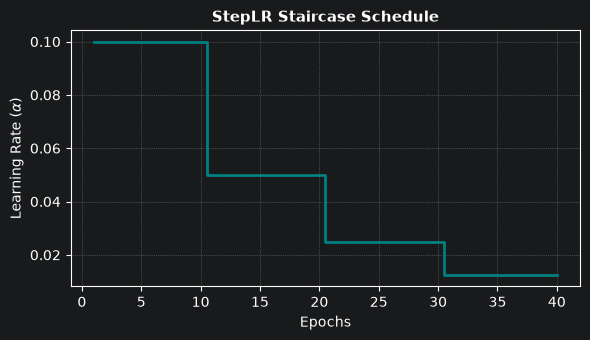

In [4]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 41)
# Drop lr by factor of 0.5 every 10 epochs
lr = 0.1 * (0.5 ** ((epochs - 1) // 10))

plt.figure(figsize=(6, 3.5))
plt.step(epochs, lr, where='mid', color='teal', linewidth=2)
plt.title("StepLR Staircase Schedule", fontsize=11, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel(r"Learning Rate ($\alpha$)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Cosine Annealing
* Definition: A scheduler that follows the shape of a cosine half-wave, smoothly decreasing the learning rate from a peak down to near zero.
* Use Cases:
    * Modern deep learning training regimens (e.g., Vision Transformers, ResNets).
* Pros:
    * Provides a smooth, continuous decrease without jarring drops, improving ultimate generalization.
* Cons:
    * Requires specifying the exact total number of epochs in advance.

### Visualizing Cosine Annealing Curve

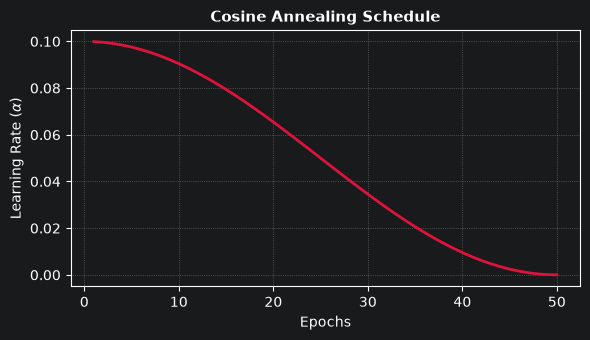

In [5]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 51)
T_max = 50
eta_min = 0.0
eta_max = 0.1

# Cosine annealing formula
lr = eta_min + 0.5 * (eta_max - eta_min) * (1 + np.cos(np.pi * epochs / T_max))

plt.figure(figsize=(6, 3.5))
plt.plot(epochs, lr, color='crimson', linewidth=2)
plt.title("Cosine Annealing Schedule", fontsize=11, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel(r"Learning Rate ($\alpha$)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 6. ReduceLROnPlateau
* Definition: An adaptive scheduler that lowers the learning rate by a specific factor when a monitored validation metric (like loss) stops improving.
* Use Cases:
    * Complex optimization landscapes where optimal decay milestones are unknown.
* Pros:
    * Automatically reacts to performance stalls and training plateaus without manual scheduling.
* Cons:
    * Can accidentally trigger due to temporary noise fluctuations in validation curves.

### Visualizing ReduceLROnPlateau Reactive Drops

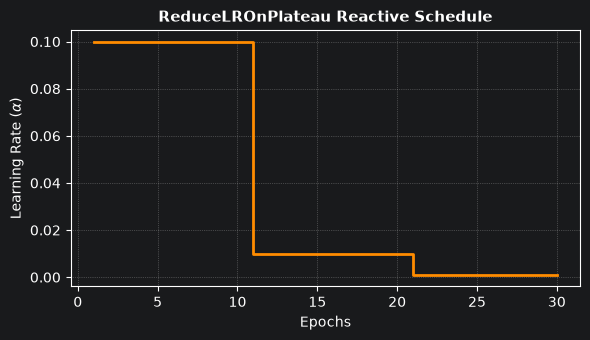

In [6]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 31)
# Simulated drops when plateauing
lr = np.where(epochs <= 10, 0.1, np.where(epochs <= 20, 0.01, 0.001))

plt.figure(figsize=(6, 3.5))
plt.step(epochs, lr, where='post', color='darkorange', linewidth=2)
plt.title("ReduceLROnPlateau Reactive Schedule", fontsize=11, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel(r"Learning Rate ($\alpha$)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 7. One Cycle Policy
* Definition: A super-convergence policy that ramps up the learning rate from a low value to a peak while reducing momentum, then drops both down to a minimum.
* Use Cases:
    * Training deep networks in a fraction of standard training time.
* Pros:
    * Drastically reduces total training time while frequently boosting final model accuracy.
* Cons:
    * Highly sensitive to maximum learning rate selection and phase boundary configurations.

### Visualizing One Cycle Policy Curve

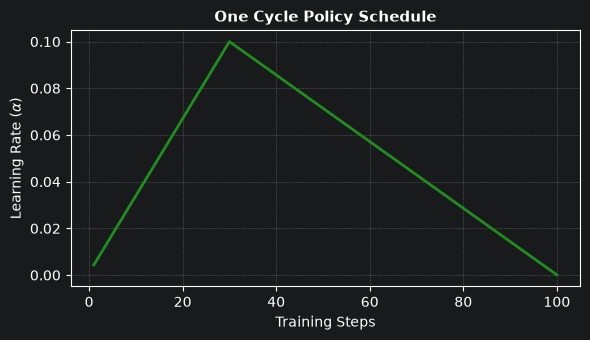

In [7]:
import numpy as np
import matplotlib.pyplot as plt

steps = np.arange(1, 101)
# Triangular one-cycle shape: up for 30 steps, down for 70 steps
peak_step = 30
lr = np.where(steps <= peak_step,
              0.001 + (0.1 - 0.001) * (steps / peak_step),
              0.1 - (0.1 - 0.0001) * ((steps - peak_step) / (100 - peak_step)))

plt.figure(figsize=(6, 3.5))
plt.plot(steps, lr, color='forestgreen', linewidth=2)
plt.title("One Cycle Policy Schedule", fontsize=11, fontweight='bold')
plt.xlabel("Training Steps")
plt.ylabel(r"Learning Rate ($\alpha$)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()